# Regression & Classification on Car Data
In this project, I aim to build and evaluate multiple machine learning models for two main tasks:

- **Regression** → Predicting car prices
- **Classification** → Predicting car categories/classes

The goal is not only to find the best-performing models, but also to **understand how and why they make predictions**, using interpretability tools such as SHAP and LIME.

Through this process, I analyze data preprocessing, model performance, feature importance, and model explainability, in order to draw meaningful conclusions about the dataset and the models.

# Code Setup

## Loading Data

In this step, I import all necessary libraries and load two datasets:

- A **regression dataset** for predicting car prices
- A **classification dataset** for predicting categorical labels

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import shap
from lime.lime_tabular import LimeTabularExplainer
from IPython.display import display, HTML


In [14]:
reg_df = pd.read_csv("../Datasets/ModInter/reg.csv")
clf_df = pd.read_csv("../Datasets/ModInter/classif.csv")

### What I do here:
- Separate features (`X`) and target (`y`)
- Handle problematic values such as:
  - Infinite values
  - Extremely large numbers
  - Missing values
- Clean the dataset to ensure stability during training

In [15]:
reg_target = 'price'

Xr = reg_df.drop(columns=[reg_target])
yr = reg_df[reg_target]

reg_df = reg_df.replace([np.inf, -np.inf], np.nan)

reg_df = reg_df[(reg_df.select_dtypes(include=[np.number]) < 1e308).all(axis=1)]

reg_df = reg_df.dropna()

## Data Preparation for Modeling

In this step, I prepare the data for training:
- Split data into:
  - **Training set (80%)**
  - **Testing set (20%)**
- Convert categorical variables using **one-hot encoding**
- Align test set columns with training set
- Normalize features using **StandardScaler**

In [16]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, random_state=42
)

Xr_train = pd.get_dummies(Xr_train)
Xr_test = pd.get_dummies(Xr_test)

Xr_test = Xr_test.reindex(columns=Xr_train.columns, fill_value=0)

scaler = StandardScaler()

Xr_train = Xr_train.apply(pd.to_numeric, errors='coerce')
Xr_test = Xr_test.apply(pd.to_numeric, errors='coerce')

Xr_train = Xr_train.replace([np.inf, -np.inf], np.nan)
Xr_test = Xr_test.replace([np.inf, -np.inf], np.nan)

Xr_train = Xr_train.fillna(0)
Xr_test = Xr_test.fillna(0)

Xr_train = Xr_train.clip(-1e6, 1e6)
Xr_test = Xr_test.clip(-1e6, 1e6)

Xr_train_scaled = scaler.fit_transform(Xr_train)
Xr_test_scaled = scaler.transform(Xr_test)

## Training and Evaluating Regression Models

I train multiple regression models:

- Linear Regression
- K-Nearest Neighbors (KNN)
- Decision Tree
- Random Forest

In [17]:
reg_models = {
    "Linear Regression": LinearRegression(),
    "KNN": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest": RandomForestRegressor(random_state=42)
}

reg_results = []

for name, model in reg_models.items():
    model.fit(Xr_train_scaled, yr_train)
    preds = model.predict(Xr_test_scaled)

    reg_results.append({
        "Model": name,
        "MAE": mean_absolute_error(yr_test, preds),
        "RMSE": np.sqrt(mean_squared_error(yr_test, preds)),
        "R2": r2_score(yr_test, preds)
    })

reg_results_df = pd.DataFrame(reg_results)
print(reg_results_df)

best_reg_model_name = reg_results_df.sort_values(by="R2", ascending=False).iloc[0]["Model"]
best_reg_model = reg_models[best_reg_model_name]

print(f"Best regression model: {best_reg_model_name}")

               Model            MAE          RMSE        R2
0  Linear Regression  320086.890495  1.047644e+06  0.673056
1                KNN  623932.753623  1.500287e+06  0.329505
2      Decision Tree   11072.463768  7.252965e+04  0.998433
3      Random Forest    8925.884058  5.770095e+04  0.999008
Best regression model: Random Forest


### Evaluation Metrics:
- **MAE (Mean Absolute Error)** → average error
- **RMSE (Root Mean Squared Error)** → penalizes large errors
- **R² Score** → how well the model explains variance

### Interpretation:
- Random Forest performs best → almost perfect prediction
- Decision Tree also performs extremely well
- Linear Regression struggles → likely due to non-linear relationships
- KNN performs poorly → not suitable for this dataset

### Conclusion:
**Random Forest is the best regression model**, because:
- Highest R²
- Lowest errors
- Handles complex patterns well

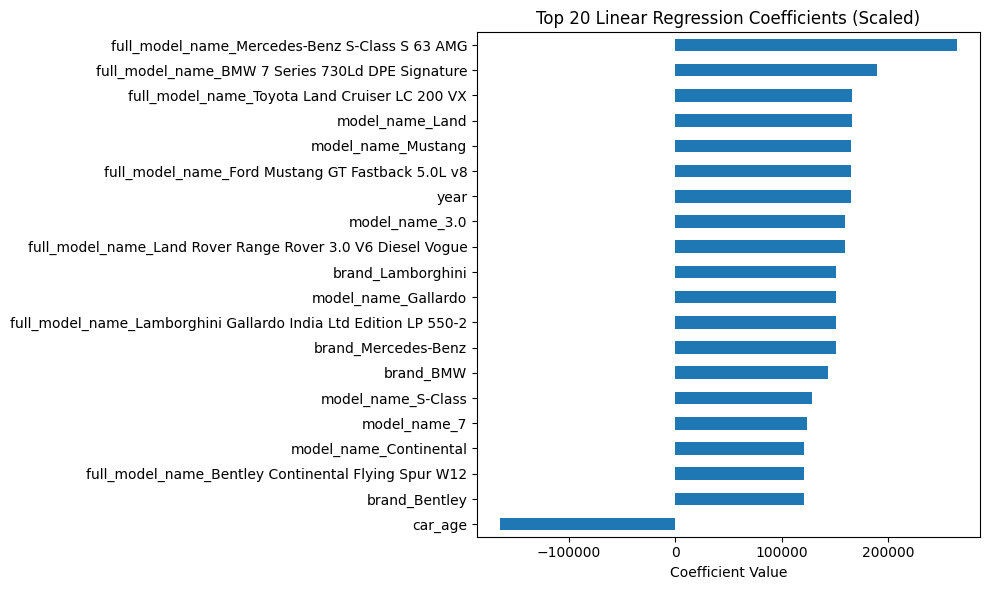

In [18]:
lin_model = reg_models["Linear Regression"]
coeffs = pd.Series(lin_model.coef_, index=Xr_train.columns)
coeffs = coeffs.sort_values()

top_n = 20
coeffs_top = coeffs.reindex(coeffs.abs().sort_values(ascending=False).head(top_n).index)

plt.figure(figsize=(10, 6))
coeffs_top.sort_values().plot(kind='barh')

plt.title("Top 20 Linear Regression Coefficients (Scaled)")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()

## Feature Importance

This plot shows the **top 20 most influential features** in the Linear Regression model.

What I observe:
- Some features have strong positive impact → increase price
- Others have negative impact → decrease price
- At this point, Large coefficients = strong influence

### Conclusion:
Even though Linear Regression is not the best model, it helps me understand **which features matter most**.

## Preparing Data for Classification

Now I switch to the classification problem.

 Steps:
- Separate features and target class
- Apply:
  - Train/test split
  - One-hot encoding
  - Feature scaling

Goal:
Prepare the dataset so classification models can:
- Learn patterns
- Predict correct categories

In [19]:
clf_target = 'class'

Xc = clf_df.drop(columns=[clf_target])
yc = clf_df[clf_target]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42
)

Xc_train = pd.get_dummies(Xc_train)
Xc_test = pd.get_dummies(Xc_test)

Xc_test = Xc_test.reindex(columns=Xc_train.columns, fill_value=0)

scaler_c = StandardScaler()
Xc_train_scaled = scaler_c.fit_transform(Xc_train)
Xc_test_scaled = scaler_c.transform(Xc_test)

## Training and Evaluating Classification Models

I train multiple classifiers:

- Logistic Regression
- KNN
- Decision Tree
- Random Forest
- Naive Bayes

Metrics used:
- Accuracy
- Precision
- Recall
- F1 Score (most important)

In [20]:
clf_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Naive Bayes": GaussianNB()
}

clf_results = []
trained_clf_models = {}

for name, model in clf_models.items():
    model.fit(Xc_train_scaled, yc_train)
    preds = model.predict(Xc_test_scaled)

    trained_clf_models[name] = model

    clf_results.append({
        "Model": name,
        "Accuracy": accuracy_score(yc_test, preds),
        "Precision": precision_score(yc_test, preds, average='weighted'),
        "Recall": recall_score(yc_test, preds, average='weighted'),
        "F1": f1_score(yc_test, preds, average='weighted')
    })

clf_results_df = pd.DataFrame(clf_results)
print(clf_results_df)

best_clf_model_name = clf_results_df.sort_values(by="F1", ascending=False).iloc[0]["Model"]
best_clf_model = trained_clf_models[best_clf_model_name]

print(f"Best classification model: {best_clf_model_name}")

                 Model  Accuracy  Precision    Recall        F1
0  Logistic Regression  0.619261   0.619154  0.619261  0.619171
1                  KNN  0.609556   0.636746  0.609556  0.613325
2        Decision Tree  0.661068   0.661489  0.661068  0.660983
3        Random Forest  0.746174   0.748462  0.746174  0.746119
4          Naive Bayes  0.548712   0.535854  0.548712  0.538116
Best classification model: Random Forest


### Interpretation:
- Random Forest clearly outperforms all models
- Naive Bayes performs worst → assumptions too simple
- Logistic Regression struggles with complex patterns

### Conclusion:
**Random Forest is the best classification model**

## Confusion Matrix Analysis

This heatmap shows how well the best model (Random Forest) classifies data.

What I look for:
- Diagonal values → correct predictions
- Off-diagonal values → errors

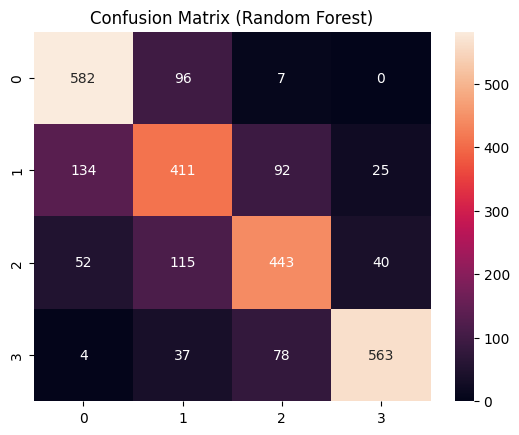

In [21]:
best_preds = best_clf_model.predict(Xc_test_scaled)

cm = confusion_matrix(yc_test, best_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title(f"Confusion Matrix ({best_clf_model_name})")
plt.show()

### Observations:
- Most predictions are correct (strong diagonal)
- Some misclassifications exist, but relatively low

### Conclusion:
The model is **accurate and reliable**, but still makes minor mistakes.

## Model Explainability with SHAP

This plot shows how features influence predictions globally.

What SHAP tells me:
- Which features matter most
- Whether they increase or decrease predictions
- Impact distribution across dataset

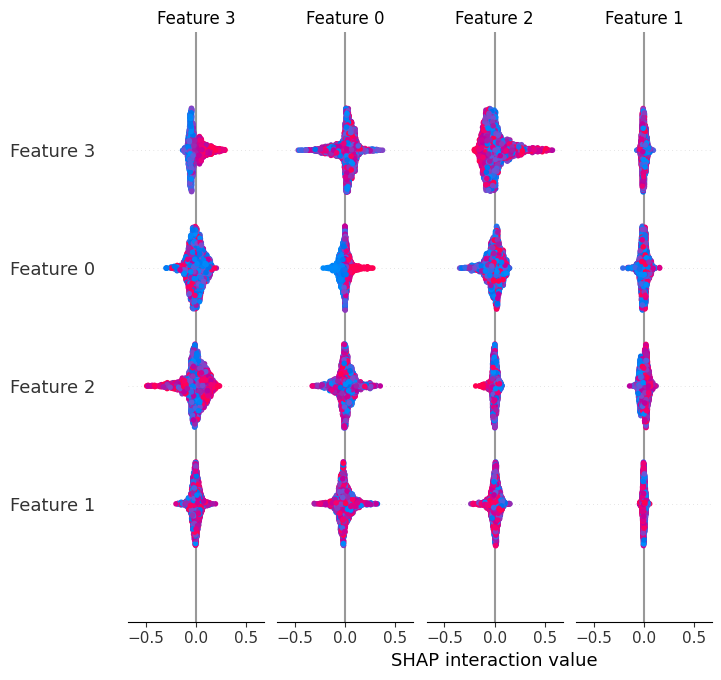

In [22]:
explainer = shap.TreeExplainer(best_clf_model)
shap_values = explainer.shap_values(Xc_test_scaled, check_additivity=False)

shap.summary_plot(shap_values, Xc_test_scaled)

explainer_lime = LimeTabularExplainer(
    Xr_train_scaled,
    feature_names=Xr_train.columns,
    mode='regression'
)

preds_reg = best_reg_model.predict(Xr_test_scaled)
errors = np.abs(yr_test - preds_reg)

worst_idx = np.argmax(errors)

exp = explainer_lime.explain_instance(
    Xr_test_scaled[worst_idx],
    best_reg_model.predict
)

### Interpretation:
- Features at the top = most important
- Red = high value, Blue = low value
- Horizontal spread = strength of influence

### Conclusion:
SHAP confirms that:
- The model relies on a few key features
- Relationships are complex and non-linear

This explains why Random Forest performs so well.

## Local Explanation with LIME

This plot explains **one specific prediction** (the worst predicted example).

In [23]:
lime_html = exp.as_html()

lime_html = f"""
<div style="background-color:white; color:black; padding:20px;">
{lime_html}
</div>
"""

display(HTML(lime_html))

### What I observe:
- Each feature contributes positively or negatively
- Example:
  - `inv_car_price` strongly decreases prediction
  - Some categorical features slightly influence result

### Conclusion:
LIME helps me understand:
*Why the model made a specific mistake*

This is extremely useful for debugging models.

# Final Conclusion

After completing both regression and classification tasks, I can conclude:

## Best Models:
- **Regression → Random Forest (R² ≈ 0.999)**
- **Classification → Random Forest (F1 ≈ 0.746)**

## Key Insights:
- Tree-based models outperform all others
- The dataset contains **non-linear relationships**
- Simpler models (Linear, Naive Bayes) fail to capture complexity

## Explainability Findings:
- SHAP shows global feature importance
- LIME explains individual predictions
- Some features strongly dominate predictions

## Critical Thinking:
Although performance is extremely high:
- The regression result (R² ≈ 0.999) may indicate **overfitting**
- The model might memorize rather than generalize

### Final Verdict:
Random Forest is the best overall model  
Interpretability tools confirm its behavior  
The pipeline is complete and robust  

This project demonstrates a full machine learning workflow:
from data cleaning → modeling → evaluation → explanation.